In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing the dataset 
df = pd.read_csv('Titanic-Dataset.csv')

In [3]:
# Dataset Shape
df.shape

(891, 12)

In [4]:
#data preview
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# The columns of the dataset
df.columns.values

array(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype=object)

In [6]:
# Information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# Observing the missing values of columns
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
# Dropping the cabin column
df.drop(columns=['Cabin'],inplace=True)

In [9]:
# Imputting missing values to the age column
# Strategy - Mean

df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\sajib\AppData\Local\Temp\ipykernel_9112\2041131655.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [10]:
# Imputting missing vlues for the Embarked column 
# Strategy - most appeard value

df['Embarked'].value_counts()

df['Embarked'].fillna('S', inplace=True)

C:\Users\sajib\AppData\Local\Temp\ipykernel_9112\2283964058.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna('S', inplace=True)


In [11]:
# Checkeng the SivSP values
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [12]:
# Checkeng the Parch values
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [13]:
#Changing datatype of some columns

df['Survived']=df['Survived'].astype('category')
df['Pclass']=df['Pclass'].astype('category')
df['Sex']=df['Sex'].astype('category')
df['Age']=df['Age'].astype('int')
df['Embarked']=df['Embarked'].astype('category')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    int64   
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(4), float64(1), int64(4), object(2)
memory usage: 52.8+ KB


In [15]:
# Summary of the dataset
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.544332,0.523008,0.381594,32.204208
std,257.353842,13.013778,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,29.000000,0.000000,0.000000,14.454200
75%,668.500000,35.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


Out of 891, 62% people died in accident.


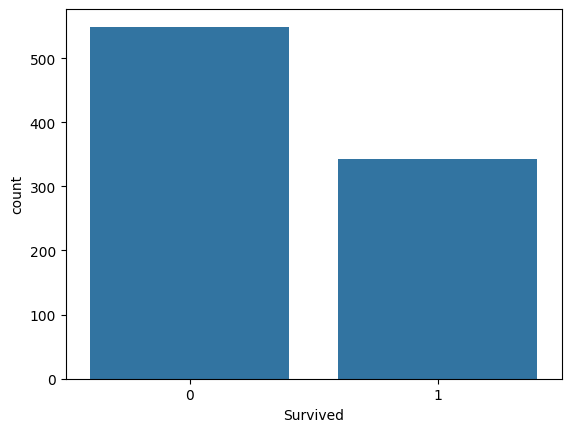

In [59]:
# Analysis of Survived column
sns.countplot(x='Survived', data=df)
death_percent = round((df['Survived'].value_counts().values[0]/891)*100)
print('Out of 891, {}% people died in accident.'.format(death_percent))

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: count, dtype: float64


<Axes: xlabel='Pclass', ylabel='count'>

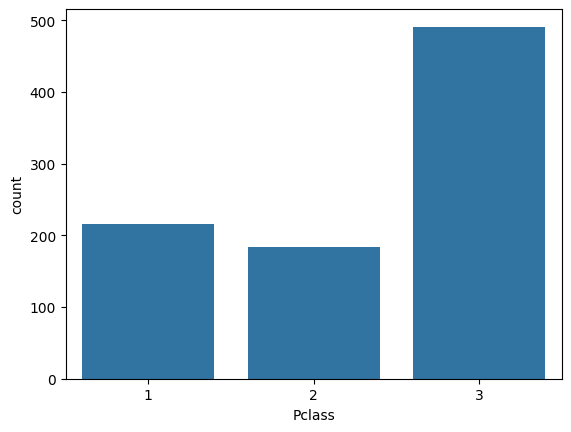

In [58]:
# Analysis of Passenger column
print((df['Pclass'].value_counts()/891)*100)
sns.countplot(x='Pclass', data=df)

# So Passenger Class 3 is the most crowded class

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64


<Axes: xlabel='Sex', ylabel='count'>

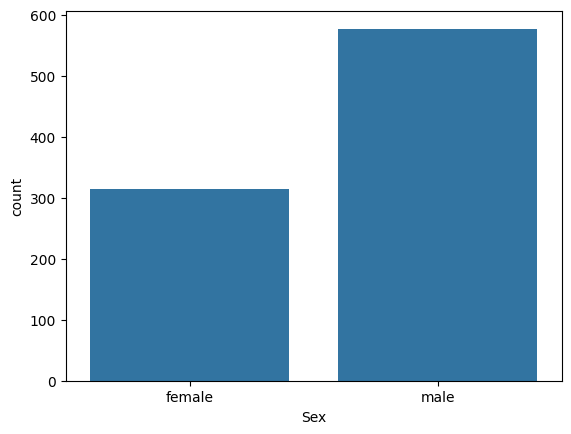

In [ ]:
# Analysis of male and female number of the ship
print((df['Sex'].value_counts()/891)*100)
sns.countplot(x='Sex', data=df)



SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


<Axes: xlabel='SibSp', ylabel='count'>

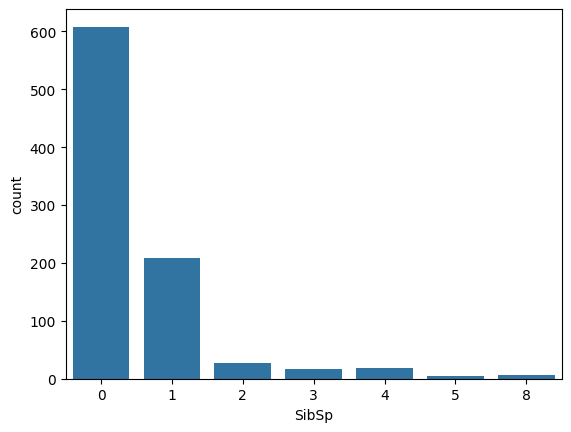

In [ ]:
#Analyzing the number of siblings or spouse
print(df['SibSp'].value_counts())

sns.countplot(x='SibSp', data=df)

Parch
0    76.094276
1    13.243547
2     8.978676
5     0.561167
3     0.561167
4     0.448934
6     0.112233
Name: count, dtype: float64


<Axes: xlabel='Parch', ylabel='count'>

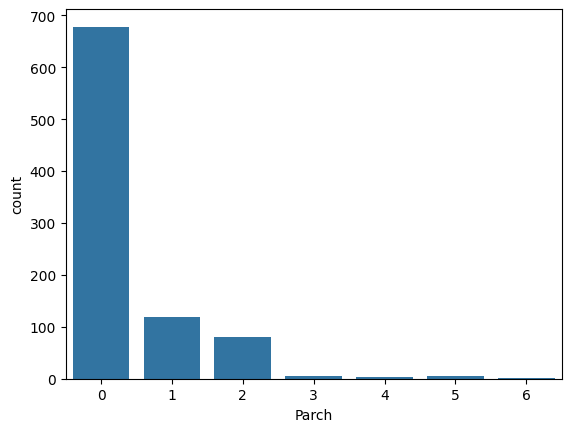

In [ ]:
# Analysis the number of parent and child 
print((df['Parch'].value_counts()/891) * 100)
sns.countplot(x='Parch', data=df)

Embarked
S    72.502806
C    18.855219
Q     8.641975
Name: count, dtype: float64


<Axes: xlabel='Embarked', ylabel='count'>

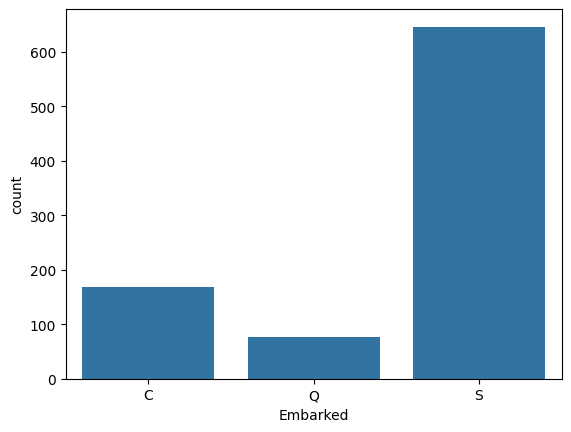

In [ ]:
# Anlysis the destination of passengers
print((df['Embarked'].value_counts()/891)*100)
sns.countplot(x='Embarked',data=df)

0.45956263424701577
0.9865867453652877


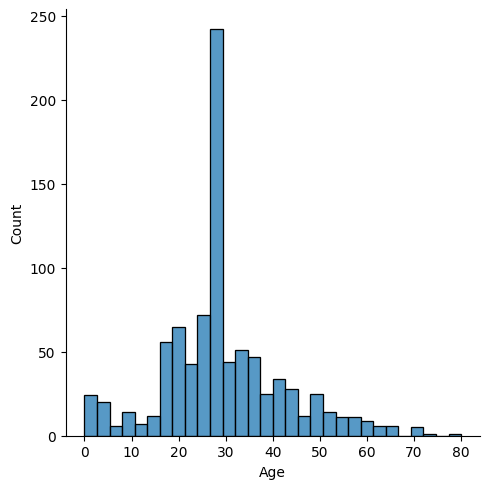

In [68]:
# Analysis of the passenger age
sns.displot(x='Age', data=df)
print(df['Age'].skew())
print(df['Age'].kurt())


<Axes: xlabel='Age'>

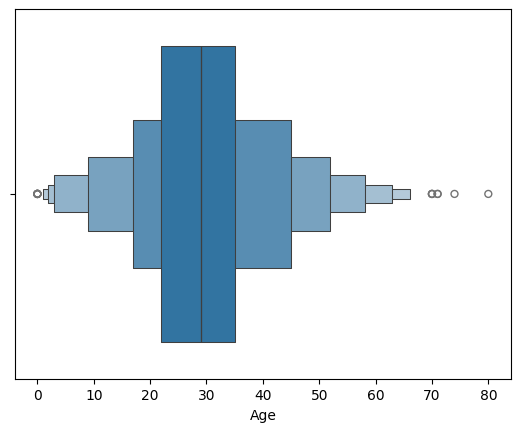

In [70]:
sns.boxenplot(x='Age', data=df)

In [ ]:
# Result of different age group that are less visible on bloxplot

print("People with age in between 60 and 70 are",df[(df['Age']>60) & (df['Age']<70)].shape[0])
print("People with age greater than 70 and 75 are",df[(df['Age']>=70) & (df['Age']<=75)].shape[0])
print("People with age greater than 75 are",df[df['Age']>75].shape[0])

print('-'*50)

print("People with age between 0 and 1",df[df['Age']<1].shape[0])

People with age in between 60 and 70 are 15
People with age greater than 70 and 75 are 6
People with age greater than 75 are 1
--------------------------------------------------
People with age between 0 and 1 7


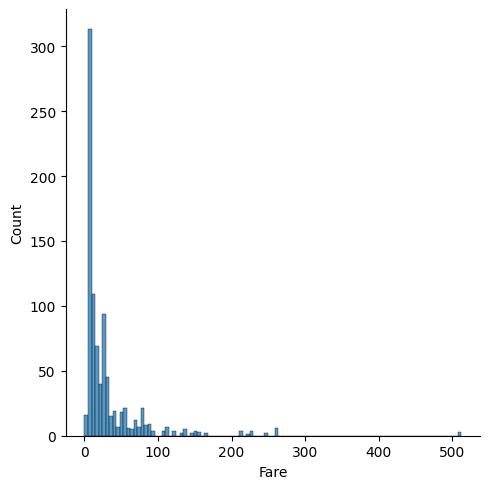

In [75]:
# Analysis of ticket fare in different pirces
sns.displot(x='Fare', data=df)

In [76]:
print(df['Fare'].skew())
print(df['Fare'].kurt())

4.787316519674893
33.39814088089868


<Axes: xlabel='Fare'>

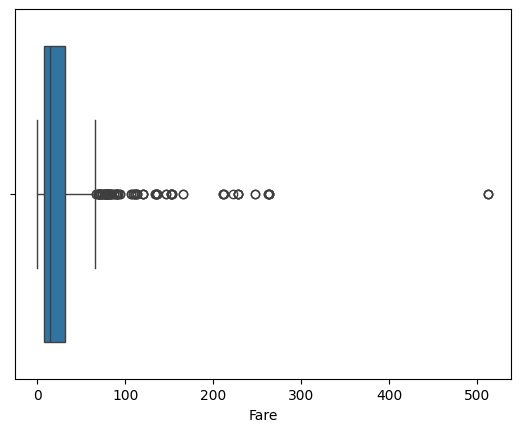

In [77]:
sns.boxplot(x='Fare', data=df)

In [ ]:
# Result of different fare group that are less visible on bloxplot

print("People with fare in between $200 and $300",df[(df['Fare']>200) & (df['Fare']<300)].shape[0])
print("People with fare in greater than $300",df[df['Fare']>300].shape[0])

People with fare in between $200 and $300 17
People with fare in greater than $300 3


Survived,0,1
Pclass,,
1,37.0,63.0
2,52.7,47.3
3,75.8,24.2


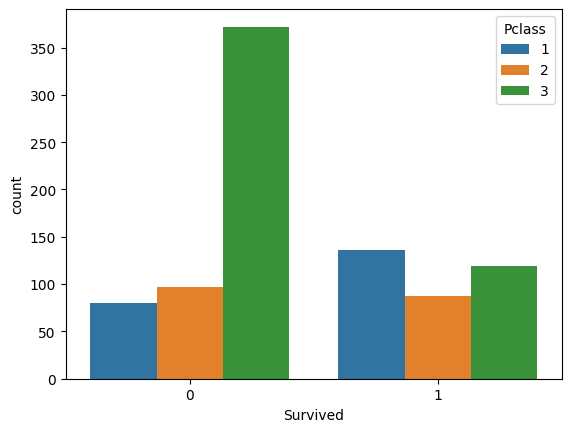

In [81]:
# Analysis of Survived column with Pclass column

sns.countplot(x='Survived', hue='Pclass', data=df)
pd.crosstab(df['Pclass'], df['Survived']).apply(lambda r: round((r/r.sum())*100,1), axis=1)

Travelling in Passenger class 3 was deadliest compare to Passenger class 1 and 2.

Survived,0,1
Sex,,
female,25.8,74.2
male,81.1,18.9


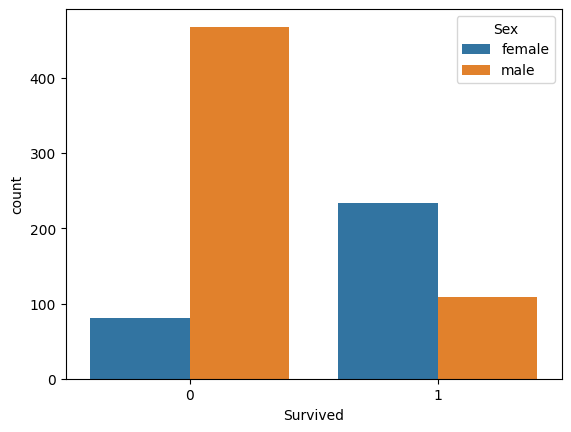

In [84]:
# Analysis of Survived column with Sex column

sns.countplot(x='Survived', hue='Sex', data=df)
pd.crosstab(df['Sex'], df['Survived']).apply(lambda r: round((r/r.sum())*100,1), axis=1)

Females are safer then Males.

Survived,0,1
Embarked,,
C,44.6,55.4
Q,61.0,39.0
S,66.1,33.9


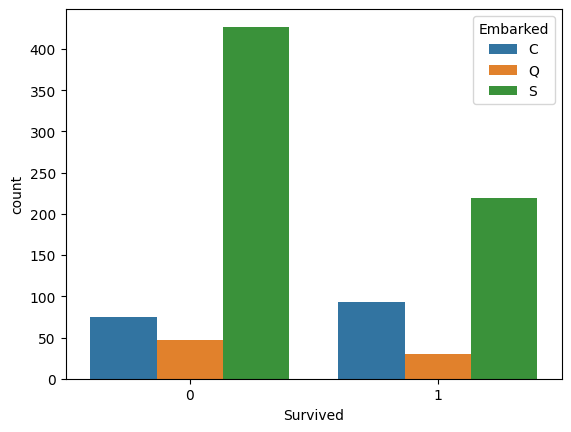

In [86]:
# Analysis of Survived column with Embarked column

sns.countplot(x='Survived', hue='Embarked', data=df)
pd.crosstab(df['Embarked'], df['Survived']).apply(lambda r: round((r/r.sum())*100,1), axis=1)

Somehow, people going to C survived more.

<Axes: xlabel='Age', ylabel='Count'>

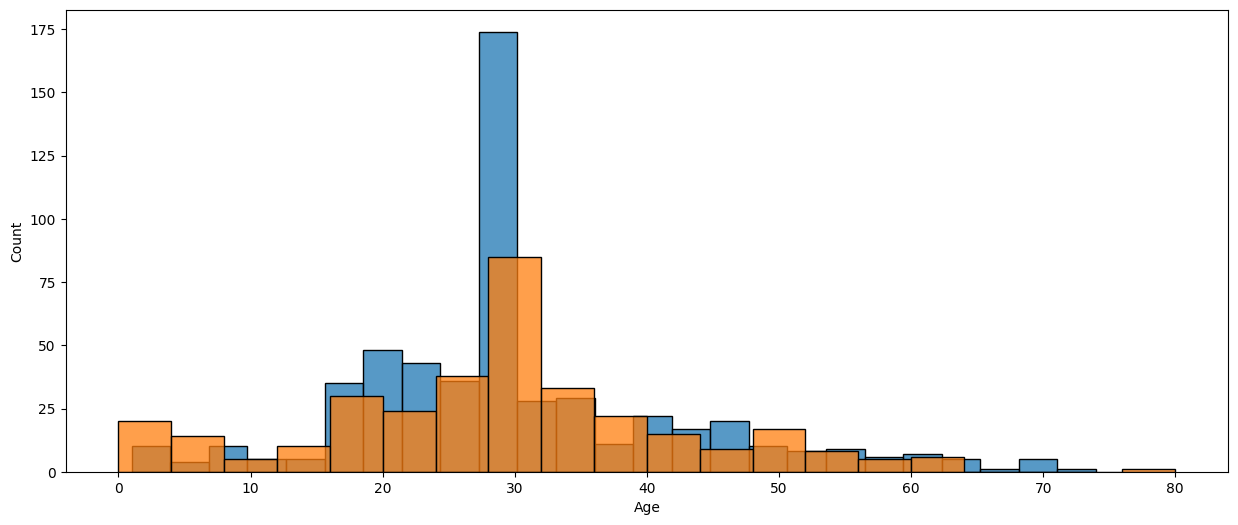

In [92]:
# Analysis of Survived column with Age column

plt.figure(figsize=(15,6))
sns.histplot(df[df['Survived']==0]['Age'])
sns.histplot(df[df['Survived']==1]['Age'])

From the graph, we and say that people in the age range of 20 to 40 had a higher chance of not surviving.

<Axes: xlabel='Fare', ylabel='Count'>

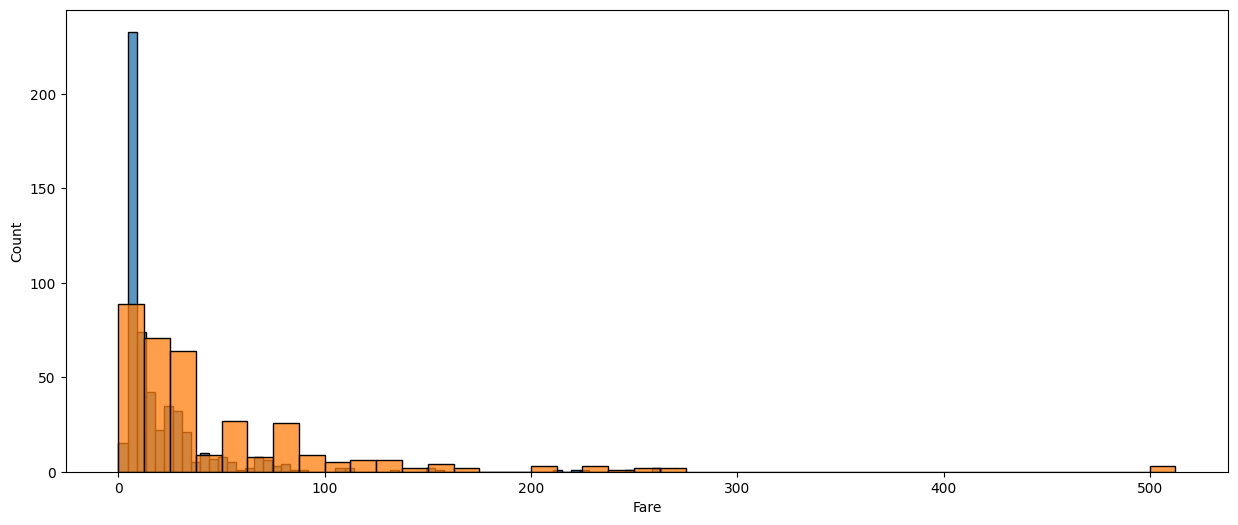

In [93]:
# Analysis of Survived column with Fare column

plt.figure(figsize=(15,6))
sns.histplot(df[df['Survived']==0]['Fare'])
sns.histplot(df[df['Survived']==1]['Fare'])

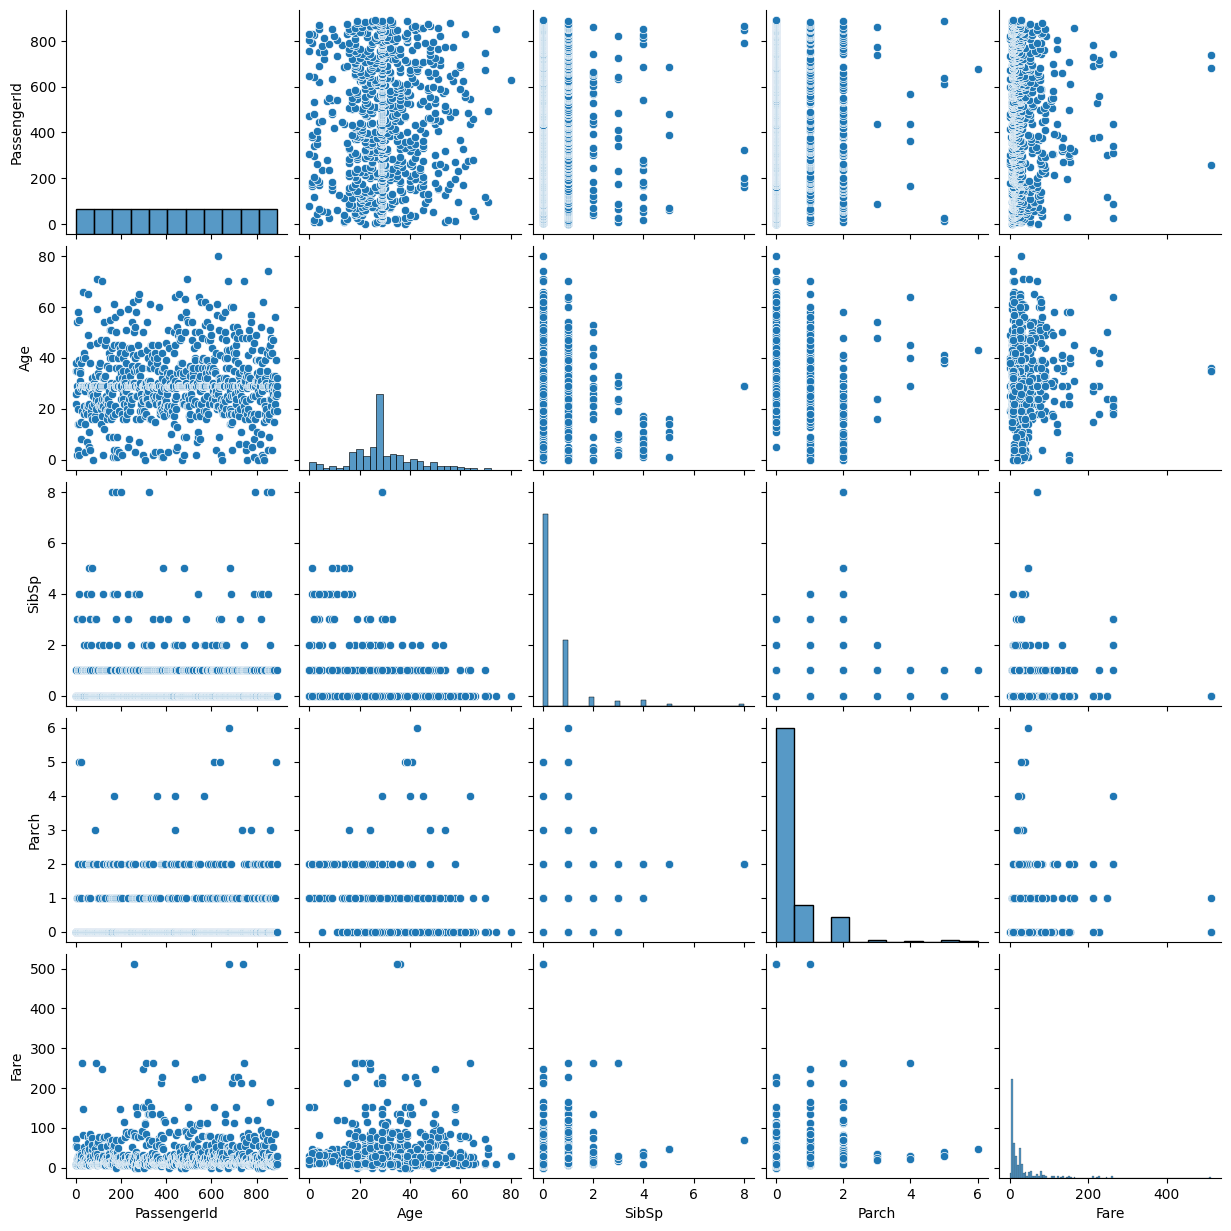

In [94]:
sns.pairplot(df)

In [96]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
107,108,1,3,"Moss, Mr. Albert Johan",male,29,0,0,312991,7.7750,S
143,144,0,3,"Burke, Mr. Jeremiah",male,19,0,0,365222,6.7500,Q
388,389,0,3,"Sadlier, Mr. Matthew",male,29,0,0,367655,7.7292,Q
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33,0,0,695,5.0000,S
68,69,1,3,"Andersson, Miss. Erna Alexandra",female,17,4,2,3101281,7.9250,S


In [ ]:
# Now we will create a new column by merging SibSp and Parch column

df['Family_size'] = df['Parch'] + df['SibSp']

In [103]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_size
798,799,0,3,"Ibrahim Shawah, Mr. Yousseff",male,30,0,0,2685,7.2292,C,0
106,107,1,3,"Salkjelsvik, Miss. Anna Kristine",female,21,0,0,343120,7.6500,S,0
94,95,0,3,"Coxon, Mr. Daniel",male,59,0,0,364500,7.2500,S,0
513,514,1,1,"Rothschild, Mrs. Martin (Elizabeth L. Barrett)",female,54,1,0,PC 17603,59.4000,C,1
151,152,1,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22,1,0,113776,66.6000,S,1


In [104]:
# Make a catagory for family in terms of family members
def family_type(number):
    if number==0:
        return "Alone"
    elif number>0 and number<=4:
        return "Medium"
    else:
        return "Large"

In [ ]:
# Creating another column as Family_type
df['Family_type'] = df['Family_size'].apply(family_type)

In [107]:
# Now we don't need SibSp, Parch and Family_size column so we drop them
df.drop(columns=['SibSp','Parch','Family_size'], inplace=True)

In [108]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_type
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4,347082,31.2750,S,Large
653,654,1,3,"O'Leary, Miss. Hanora ""Norah""",female,29,330919,7.8292,Q,Alone
843,844,0,3,"Lemberopolous, Mr. Peter L",male,34,2683,6.4375,C,Alone
303,304,1,2,"Keane, Miss. Nora A",female,29,226593,12.3500,Q,Alone
814,815,0,3,"Tomlin, Mr. Ernest Portage",male,30,364499,8.0500,S,Alone


In [110]:
pd.crosstab(df['Family_type'], df['Survived']).apply(lambda r: round((r/r.sum())*100,1), axis=1)

Survived,0,1
Family_type,,
Alone,69.6,30.4
Large,85.1,14.9
Medium,44.0,56.0


People travelling with smaller familes had a higher chance of surviving the accident in comparison to people with large families and travelling alone.